**Fundamentos de machine learning (ML)**

## Introdução prática com sklearn

Neste notebook vamos aprender:
- Conceitos fundamentais de ML
- Entendimento do dataset
- Pré - processamento
- Divisao treino/teste
- Treinamento de modelos
- Avaliação de desempenho

Vamos começar fazendo a importação das bibliotecas

##O que é machine learning?

ML é o ramo da inteligência artificial que desenvolve técnicas para que o computadores possam aprender com dados e melhorar seu desempenho em alguma tarefa ao longo do tempo, sem serem explicitamente programados para cada situação.

Formalmente, segundo Tom Mitchell (1997):

"Um programa de computador aprende com a experiência E em relação a alguma classe de tarefas T e medida de desempenho P, se seu desempenho em T, medido por P, melhora com a experiência E."



## 1.2 Tipos de Aprendizado

| Tipo | Descrição | Exemplos |
|------|-----------|----------|
| **Supervisionado** | Dados rotulados (entrada + saída esperada) | Classificação, Regressão |
| **Não supervisionado** | Dados não rotulados (apenas entradas) | Clusterização, Redução de dimensionalidade |
| **Por reforço** | Agente interage com ambiente e recebe recompensas | Jogos, Robótica |
| **Semi-supervisionado** | Mistura de rotulados e não rotulados | Classificação com poucos rótulos |

Neste notebook, focaremos em **aprendizado supervisionado**, que é a base para a maioria das aplicações práticas.

## 1.3 Conceitos Fundamentais

- **Instância (ou amostra):** cada linha dos dados.
- **Feature (atributo):** variável de entrada (coluna).
- **Target (rótulo):** variável que queremos prever.
- **Modelo:** representação matemática que mapeia features → target.
- **Treinamento:** processo de ajustar os parâmetros do modelo aos dados.
- **Generalização:** capacidade do modelo de performar bem em dados não vistos.
- **Overfitting:** modelo se ajusta demais aos dados de treino, perdendo generalização.
- **Underfitting:** modelo é muito simples para capturar a complexidade dos dados.



## 1.4 Trade-off Viés-Variancia
- Viés(bias): erro devido a suposições errôneas no algoritmo. Alto viés -> underfitting
- Variância(variance) : Erro devido a sensibilidade a flutuações nos dados de treino. Alta variância -> Overfitting

O objetivo é encontrar um equilivrio que minimize o erro total ( erro = vies² + variancia + erro irredutível)



## Entendendo o dataset
Antes de começarmos a modelagem, é crucial conhecer os dados. O EDA é a etapa que nos permite identificar padrões, anomalias, relacionamentos, orientando no pre-processamento

### Nessa aula vamos trabalhar com 3 conjuntos de dados clássicos :
- Iris (classificação de flores) : Pequeno, balanceado, todas as features numéricas
- California Housing( regressão de preços de imagens): Médio porte, features numericas
- Titanic (classificação de sobrevivencia) : Contem dados ausentes e variáveis categóricas


In [4]:
# Importações iniciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, fetch_california_housing

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
np.random.seed(42)

In [5]:
# Carregando datasets
iris = load_iris()
X_iris = iris.data #Definindo um X e y
y_iris = iris.target #Definindo a variavel alvo
feature_names_iris = iris.feature_names #Pegando o nome das features
target_names_iris = iris.target_names# Pegando o nome da variavel alvo

#Nesse caso nao temos o target_name, pois é um exemplo de classificação (sim ou nao)
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target
feature_names_housing = housing.feature_names

titanic = sns.load_dataset('titanic')

## Seleção de features
Nem todas as features são igualmente proporcionais. Selecionar as relevantes ajudam :
 - Reduzir o overfitting
 - Melhorara a interpretabilidade
 - Diminuir tempo de treinamento
 - Evitar a maldição da dimensionalidade

Métodos:
- Filtros : Baseados em estatísticas univariadas ( correlação, informação mútua, ANOVA);
- Wrappers : Usam um modelo para avaliar subconjuntos( RFE - Recursive Feature Elimination)
- Embedded : a seleção é feita durante o treinamento ( Regularização, L1, importancia em arvores)



In [7]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier

#O dataset Iris contem 4 features : Sepal lenght, sepal widht, petal lenght, petal width

# #xemplo com Iris : Selecionar as 2 melhores features com ANOVA
selector = SelectKBest(f_classif, k=2)
X_selected = selector.fit_transform(X_iris, y_iris)
print('Features selecionadas (índices):', selector.get_support(indices=True))
print('Scores:', selector.scores_)

# Usando informação mútua
selector_mi = SelectKBest(score_func=mutual_info_classif, k=2)
X_selected_mi = selector_mi.fit_transform(X_iris, y_iris)
print('Scores MI:', selector_mi.scores_)

# RFE com Random Forest
rf = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=2)
rfe.fit(X_iris, y_iris)
print('Ranking das features:', rfe.ranking_)

Features selecionadas (índices): [2 3]
Scores: [ 119.26450218   49.16004009 1180.16118225  960.0071468 ]
Scores MI: [0.5113651  0.29942431 0.99257309 0.98564251]
Ranking das features: [2 3 1 1]


O que esse resultado nos taz ?

1. O f_classic usa ANOVA F-value, que mede:

  O quando cada feature separa bem as classes
  
  **Quanto maior o score -> Melhor a separação entre as espécies**

Ou seja, de acordo com o nosso resultado as duas maiores sao de indice 2 e 3.

Conclusao: As medidas da pétala são muito mais discriminativas do que as da sépala.

-> Lembrando que o INDICE COMEÇA EM 0


2. SelectKBest com Informação Mutua:
  Mede : Quanto conhecer a feature reduz a incerteza sobre a classe.
  **Como no exemplo acima, quanto maior o score, melhor.**

3. RFE:
  No rfe : ranking = 1 -> Feature selecionada
           Ranking maior = Menos importante
  Features 1 e dao sao mais importntes


## Escalonamento : Normalização e padronização

Muitos algoritmos (KNN, SVM, regressão com regularização) são sensíveis a escala das features. O escalonamento coloca todas as features em uma escala comparável.

1. **Normalização (min-max scalling) :**
 $$
X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$

Resulta em valores entre 0 e 1. Útil quando os dados não seguem distribuição normal e para redes neurais.




2. **Padronização (Standard Scaling):**
$$
X_{std} = \frac{X - \mu}{\sigma}
$$
Resulta em média 0 e desvio padrao 1. É a escolha para a maioria dos modelos.

3. **Robust Scalling :**
  Usa mediana e IQR, sendo robusto a outliers.




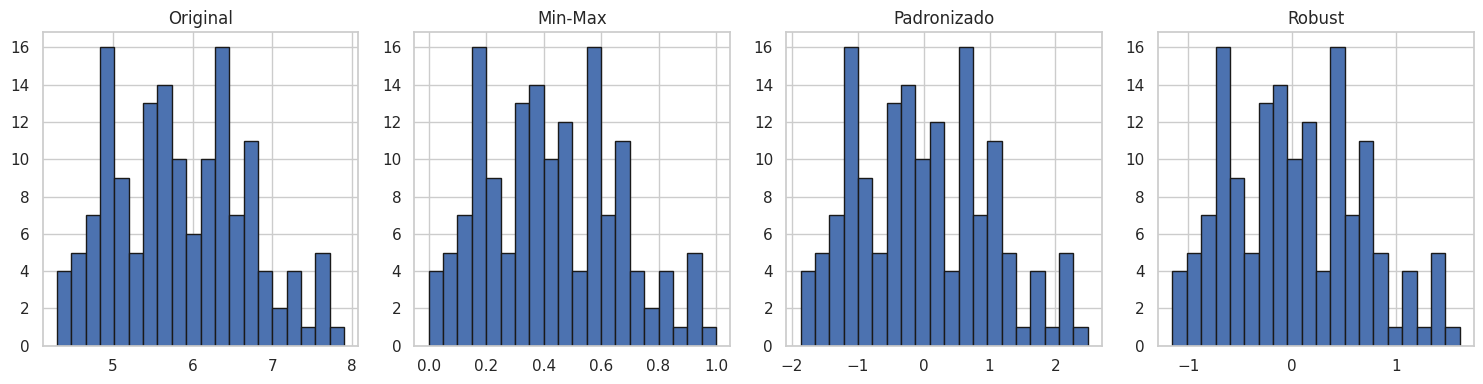

In [9]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

#Comparação no IRIs

#Normalização
scaler_mm = MinMaxScaler()
X_iris_mm = scaler_mm.fit_transform(X_iris)

#Padronziação
scaler_std = StandardScaler()
X_iris_std = scaler_std.fit_transform(X_iris)

#Robust
scaler_robust = RobustScaler()
X_iris_rob  = scaler_robust.fit_transform(X_iris)

# Visualização da primeira feature
plt.figure(figsize=(15,4))
plt.subplot(1,4,1)
plt.hist(X_iris[:,0], bins=20, edgecolor='k')
plt.title('Original')
plt.subplot(1,4,2)
plt.hist(X_iris_mm[:,0], bins=20, edgecolor='k')
plt.title('Min-Max')
plt.subplot(1,4,3)
plt.hist(X_iris_std[:,0], bins=20, edgecolor='k')
plt.title('Padronizado')
plt.subplot(1,4,4)
plt.hist(X_iris_rob[:,0], bins=20, edgecolor='k')
plt.title('Robust')
plt.tight_layout()
plt.show()

Entendimento dos gráficos:
**1. Original:**

  Valores reais das features: escala natural, media ~= 5.8, distribuição ja é aproximadamente normal

**2. MinMaxScaler:**

  TOdos os valores ficam entre 0 e 1, a forma da distribuição nao muda, apenas a escala é comprimida

  OBS : MixMax preserva a proporção relativa mas é sensivel a outliers ( se existir um valor extremo, ele 'achata' todo o resto.)

**3. StandardScaler(Padronização):**

  Média vira 0, Desvio padrao vira 1, valores passam a girar em torno de zero, podem existir valores negativos

  Interpretação : Agora os dados estão em escalas estatísticas, não física

**4. RobustScaler**

  Onde IQR : intervalo interquantil (Q3 - Q1)

  Usa mediana em vez de média, usa IQR em vez de desvio padrão, menos sensivel a outliers

  -> Parecido com StandardScaler, mas sofre menos influencias de valores extremos

## Pipeline e Column Transformers

**Pipeline** encadeia transformações e um estimador, garantindo que as mesmas transformações sejam aplicadas consistentemente nos dados de treino e teste, e facilitando a validação cruzada

**Column transformer** permite aplicar transformações diferentes a diferentes colunas ( ex: padronizações numericas, one-hot em categorias)

Exemplificando no dataset do titanic:



In [11]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

#Definindo as features
features_numericas = ['age', 'fare', 'pclass'] #Pclass como um numero ordinal
features_categoricas = ['sex', 'embarked']

#Transformadores
transformador_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')), #Trata dados faltantes como a media, ou seja, serao preenchidos com amedia
    ('scaler', StandardScaler())
])

transformador_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')), #Trata dados faltantes como missing, contant =
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

#Column Transformer
preprocessor = ColumnTransformer([
    ('num', transformador_numerico, features_numericas),
    ('cat', transformador_categorico, features_categoricas)
])

#Pipe - pipeline completo
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state = 42))
])

#Preparando dados(usando o titanic original com algumas colunas)
X_titanic = titanic[['pclass','sex', 'age', 'fare', 'embarked']]
y_titanic = titanic['survived']

#Treinando
pipe.fit(X_titanic, y_titanic)

print(f'Acuracia no treino: {pipe.score(X_titanic, y_titanic)}')

Acuracia no treino: 0.9775533108866442
